In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("insurance_dataset.csv")

df.head()

,age,driver_type,years_experience,income_band,vehicle_age,vehicle_type,vehicle_value,airbags,tracking_device,region,...,annual_mileage,speeding_score,previous_claims,fraud_flag,risk_score,base_premium,premium,claim_occurred,claim_amount,claim_type
0,59,private,41,middle,0,SUV,3.005088e+06,2,0,Mombasa,...,15844,low,0,0,0.33,150254.402493,199838.355316,0,0.0,none
1,49,taxi,31,middle,10,sedan,5.223960e+05,6,0,Rural,...,35500,medium,1,0,0.04,26119.802262,27164.594353,0,0.0,none
2,35,private,17,low,8,sedan,8.075370e+05,0,0,Nairobi,...,13719,medium,1,0,0.50,40376.852016,60565.278024,0,0.0,none
3,63,taxi,45,low,6,sedan,8.082229e+05,4,1,Nairobi,...,31607,low,1,0,0.56,40411.145448,63041.386899,0,0.0,none
4,28,taxi,10,middle,0,sedan,8.101454e+05,1,1,Nairobi,...,26988,high,0,0,0.34,40507.271620,54279.743971,0,0.0,none


In [10]:
df.describe()

,age,years_experience,vehicle_age,vehicle_value,airbags,tracking_device,policy_duration,annual_mileage,previous_claims,fraud_flag,risk_score,base_premium,premium,claim_occurred,claim_amount
count,50000.000000,50000.000000,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,5.000000e+04
mean,44.991820,26.991820,7.001060,1.381802e+06,3.509600,0.401000,7.807800,22011.71992,0.501920,0.050680,0.338985,69090.117173,94155.798499,0.08378,4.709104e+04
std,14.110139,14.110139,4.334028,9.278561e+05,2.297523,0.490106,3.347465,9312.99638,0.710131,0.219346,0.229810,46392.804190,70877.831291,0.27706,2.080007e+05
min,21.000000,3.000000,0.000000,2.403355e+05,0.000000,0.000000,3.000000,8000.00000,0.000000,0.000000,0.000000,12016.772977,12107.844556,0.00000,0.000000e+00
25%,33.000000,15.000000,3.000000,7.414970e+05,2.000000,0.000000,6.000000,13984.00000,0.000000,0.000000,0.150000,37074.847823,47213.054326,0.00000,0.000000e+00
50%,45.000000,27.000000,7.000000,1.117871e+06,4.000000,0.000000,9.000000,20056.00000,0.000000,0.000000,0.320000,55893.562858,72743.829324,0.00000,0.000000e+00
75%,57.000000,39.000000,11.000000,1.721697e+06,6.000000,1.000000,12.000000,29996.25000,1.000000,0.000000,0.490000,86084.840499,117088.044767,0.00000,0.000000e+00
max,69.000000,51.000000,14.000000,6.997445e+06,7.000000,1.000000,12.000000,39999.00000,6.000000,1.000000,1.000000,349872.269367,690482.484899,1.00000,3.933408e+06


#### Key Insights into the dataset
##### Policyholder Characteristics

- **Average age** of policyholders is **~45 years**, with a range from **21 to 69 years**.
- **Driving experience** closely mirrors age (mean ~27 years), indicating a realistic relationship between age and experience.
- The distribution is well spread (std ~14 years), allowing for meaningful segmentation across:
  - Young drivers (higher risk)
  - Mid-age drivers (typically lower risk)
  - Older drivers (potentially increasing risk again)

*Underwriting Insight:*  
Age and experience provide a strong baseline for risk segmentation, but should be treated as **non-linear predictors** rather than simple linear factors.

##### Vehicle Profile

- **Average vehicle age** is **~7 years**, with a balanced spread from new (0 years) to older vehicles (14 years).
- **Vehicle values** vary widely:
  - Median: ~1.1M
  - Maximum: ~7M
- This indicates a mix of economy and high-value vehicles in the portfolio.

*Underwriting Insight:*  
Vehicle age and value introduce both:
- **Frequency risk** (older vehicles - more breakdowns/accidents)
- **Severity risk** (higher value - larger claims)

##### Safety Features

- Average number of **airbags**: ~3.5 (range: 0–7)
- **Tracking devices** present in ~40% of vehicles

*Underwriting Insight:*  
Safety features are moderately adopted and provide:
- Risk mitigation (lower claim probability)
- Theft protection (reduced severity)

However, variation in adoption allows meaningful differentiation across policies.

##### Policy Characteristics

- **Average policy duration**: ~7.8 months
- Distribution includes short-term (3–6 months) and long-term (12 months) policies

*Underwriting Insight:*  
Shorter policies may indicate:
- Higher-risk customers (adverse selection)
- Temporary or opportunistic insurance behavior

##### Driving Behavior

- **Average annual mileage**: ~22,000 km  
  - Range: 8,000 → 40,000 km
- Indicates a mix of:
  - Low-exposure private drivers
  - High-exposure commercial usage

*Underwriting Insight:*  
Mileage acts as a proxy for **risk exposure** - higher mileage increases the likelihood of claims.

##### Claims History

- **Average previous claims**: ~0.5 per policyholder
- Majority of customers have **no prior claims**, but a small segment shows repeated claims

 *Underwriting Insight:*  
Claims history is one of the strongest predictors of future risk and supports:
- Experience-based pricing
- Risk-based segmentation

##### Fraud Indicator

- **Fraud rate**: ~5%

*Underwriting Insight:*  
This aligns with realistic insurance scenarios and enables:
- Fraud detection modeling
- Risk-adjusted underwriting decisions

##### Risk & Pricing Structure

- **Average risk score**: ~0.34  
  - Range: 0 - 1
- **Average base premium**: ~69,000
- **Average final premium**: ~94,000

*Underwriting Insight:*  
Premiums are adjusted upward based on risk, reflecting a **risk-based pricing framework**:
- Higher risk - higher premium loading
- Indicates a functioning pricing mechanism

##### Claims Overview

- **Claim rate**: ~8.38%  
- **Claim amounts**:
  - Highly skewed distribution
  - Mean: ~47,000
  - Max: ~3.9M

*Underwriting Insight:*  
This reflects a realistic insurance pattern:
- Many policies have **no claims**
- A small number of claims account for **large losses** (heavy-tailed distribution)

This reinforces the need to model:
- **Frequency (claim occurrence)**
- **Severity (claim size)**


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               50000 non-null  int64  
 1   driver_type       50000 non-null  object 
 2   years_experience  50000 non-null  int64  
 3   income_band       50000 non-null  object 
 4   vehicle_age       50000 non-null  int64  
 5   vehicle_type      50000 non-null  object 
 6   vehicle_value     50000 non-null  float64
 7   airbags           50000 non-null  int64  
 8   tracking_device   50000 non-null  int64  
 9   region            50000 non-null  object 
 10  traffic_density   50000 non-null  object 
 11  policy_duration   50000 non-null  int64  
 12  annual_mileage    50000 non-null  int64  
 13  speeding_score    50000 non-null  object 
 14  previous_claims   50000 non-null  int64  
 15  fraud_flag        50000 non-null  int64  
 16  risk_score        50000 non-null  float6

### Analysing the target variable

#### Claim Amount Distribution

In [11]:
claim_rate = df["claim_occurred"].mean()
print(f"Claim Rate: {claim_rate:.2%}")

Claim Rate: 8.38%


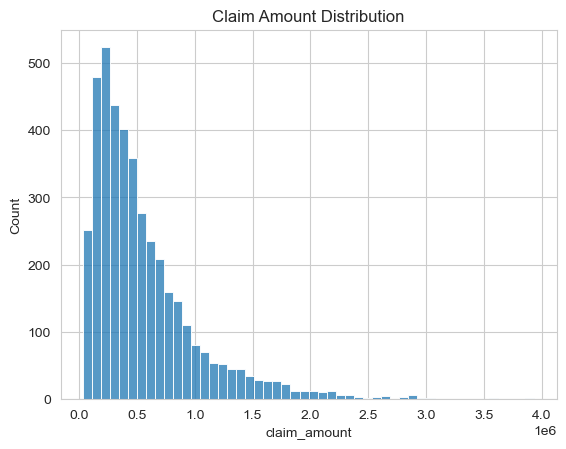

In [12]:
plt.figure()
sns.histplot(df[df["claim_amount"] > 0]["claim_amount"], bins=50)
plt.title("Claim Amount Distribution")
plt.show()

- The heavy tail indicates few very large claims

#### Policyholder Risk Analysis
##### Age vs Claims

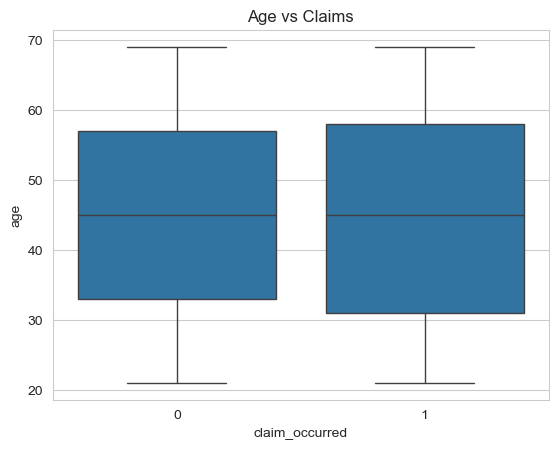

In [14]:
sns.boxplot(x="claim_occurred", y="age", data=df)
plt.title("Age vs Claims")
plt.show()

In [16]:
df.groupby(pd.cut(df["age"], bins=[20,30,50,70]), observed=True)["claim_occurred"].mean()

age
(20, 30]    0.097583
(30, 50]    0.074072
(50, 70]    0.087004
Name: claim_occurred, dtype: float64

- Young drivers - higher risk
- Older drivers - slight increase

Age is nonlinear risk (ie not just “older = safer”)

##### Driver Type Risk

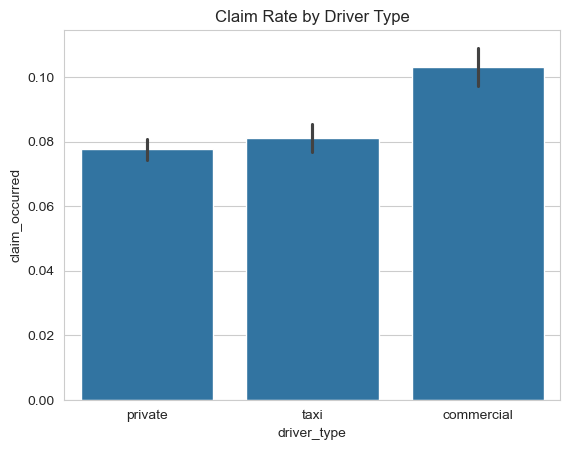

In [17]:
sns.barplot(x="driver_type", y="claim_occurred", data=df)
plt.title("Claim Rate by Driver Type")
plt.show()

Usage type is a major underwriting factor

- Commercial > Taxi > Private

#### Vehicle Risk Analysis
##### Vehicle Age

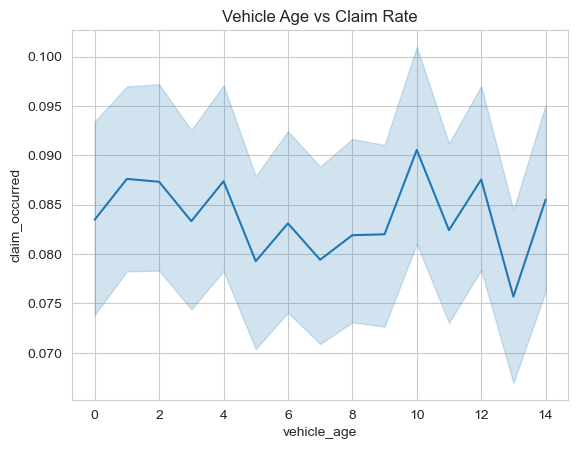

In [18]:
sns.lineplot(x="vehicle_age", y="claim_occurred", data=df)
plt.title("Vehicle Age vs Claim Rate")
plt.show()

The U-shape pattern shows:
- New - moderate
- Mid-age - lower
- Old - high

##### Vehicle Value vs Claims

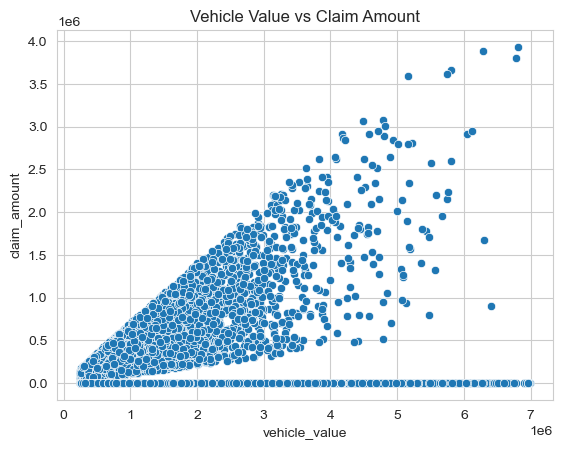

In [19]:
sns.scatterplot(x="vehicle_value", y="claim_amount", data=df)
plt.title("Vehicle Value vs Claim Amount")
plt.show()

- Larger cars - bigger claims (severity)

#### Safety Features Analysis
##### Airbags

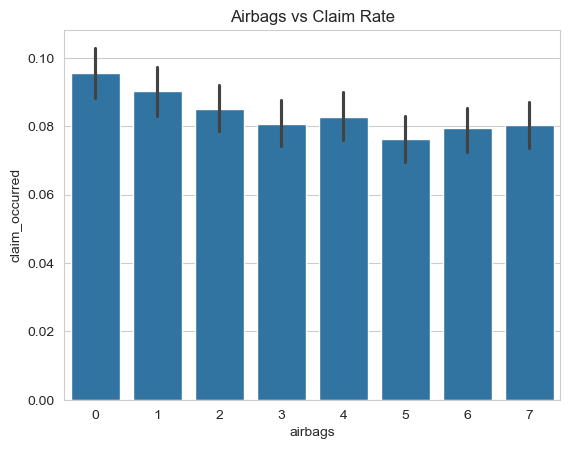

In [21]:
sns.barplot(x="airbags", y="claim_occurred", data=df)
plt.title("Airbags vs Claim Rate")
plt.show()

- More airbags - lower risk (but not perfectly linear)

##### Tracking Device

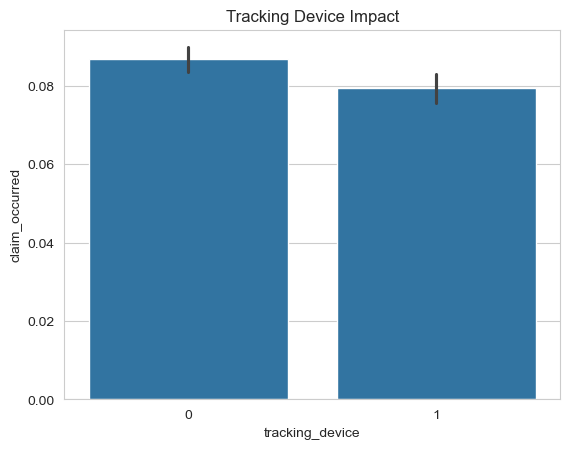

In [22]:
sns.barplot(x="tracking_device", y="claim_occurred", data=df)
plt.title("Tracking Device Impact")
plt.show()

- Anti-theft reduces claim probability and severity

#### Geographic Risk
##### Region Risk

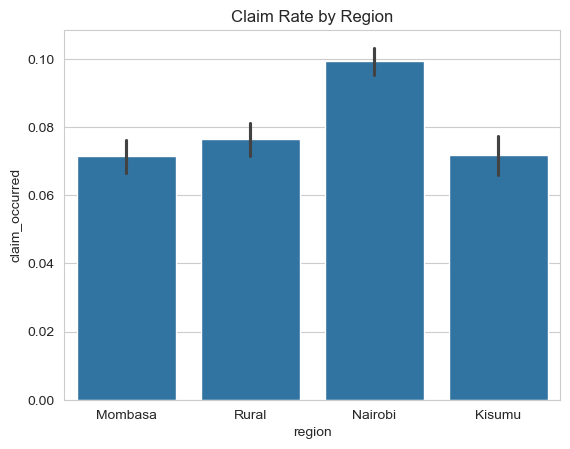

In [23]:
sns.barplot(x="region", y="claim_occurred", data=df)
plt.title("Claim Rate by Region")
plt.show()

Nairobi has the highest risk
- Urban density = more accidents

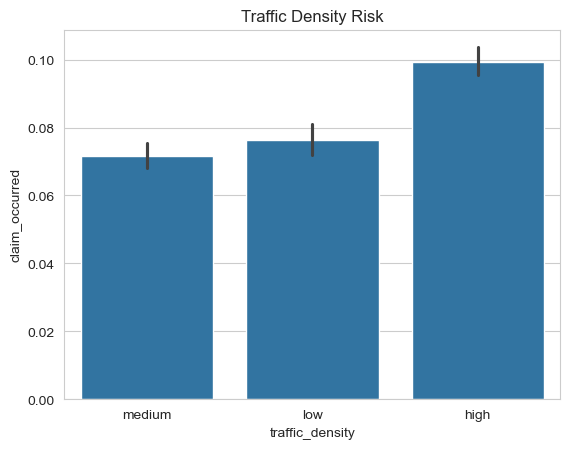

In [24]:
sns.barplot(x="traffic_density", y="claim_occurred", data=df)
plt.title("Traffic Density Risk")
plt.show()

#### Policy Design Risk
##### Policy Duration

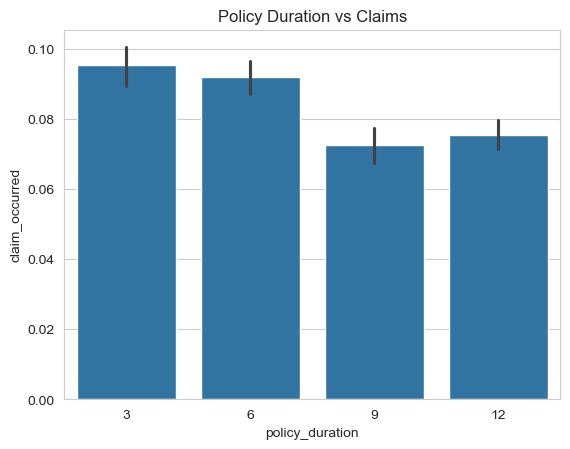

In [25]:
sns.barplot(x="policy_duration", y="claim_occurred", data=df)
plt.title("Policy Duration vs Claims")
plt.show()

Adverse selection (risky customers choose short policies)

- Short-term - higher risk

#### Behavioral Risk
##### Mileage

In [27]:
df.groupby(pd.cut(df["annual_mileage"], bins=5), observed=True)["claim_occurred"].mean()

annual_mileage
(7968.001, 14399.8]    0.077994
(14399.8, 20799.6]     0.078505
(20799.6, 27199.4]     0.084109
(27199.4, 33599.2]     0.088927
(33599.2, 39999.0]     0.096248
Name: claim_occurred, dtype: float64

- Higher mileage - higher exposure

##### Speeding Score

<Axes: xlabel='speeding_score', ylabel='claim_occurred'>

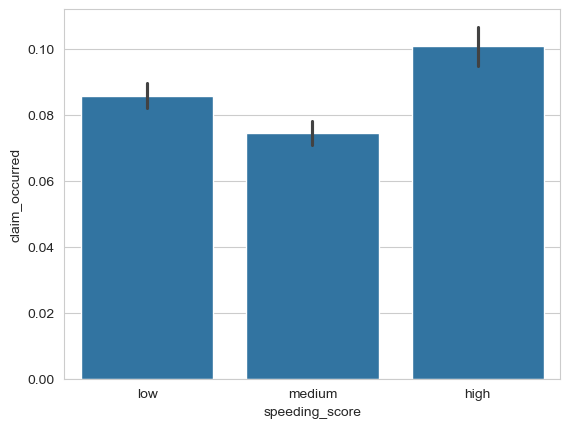

In [28]:
sns.barplot(x="speeding_score", y="claim_occurred", data=df)

- Behavioral data > demographic data

#### Claims History

<Axes: xlabel='previous_claims', ylabel='claim_occurred'>

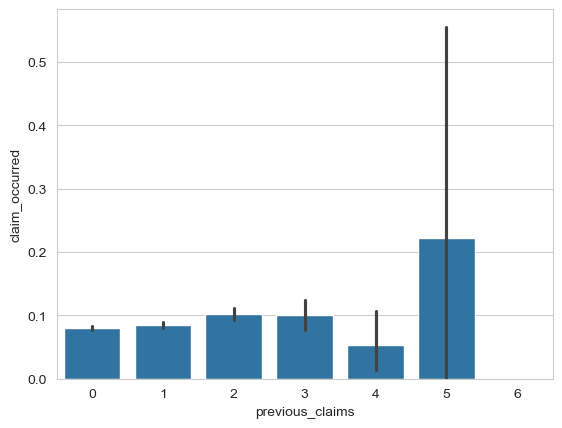

In [30]:
sns.barplot(x="previous_claims", y="claim_occurred", data=df)

#### Premium Adequacy Analysis

##### Loss Ratio

In [31]:
df["loss_ratio"] = df["claim_amount"] / df["premium"]

df["loss_ratio"].describe()

count    50000.000000
mean         0.489405
std          1.801169
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         13.760247
Name: loss_ratio, dtype: float64

##### Loss Ratio by Risk Score

In [33]:
df.groupby(pd.cut(df["risk_score"], bins=5), observed=True)["loss_ratio"].mean()

risk_score
(-0.001, 0.2]    0.427159
(0.2, 0.4]       0.502043
(0.4, 0.6]       0.521157
(0.6, 0.8]       0.554486
(0.8, 1.0]       0.607483
Name: loss_ratio, dtype: float64

- High risk - higher loss ratio

Pricing is Fair and not underpriced

#### Correlation Analysis

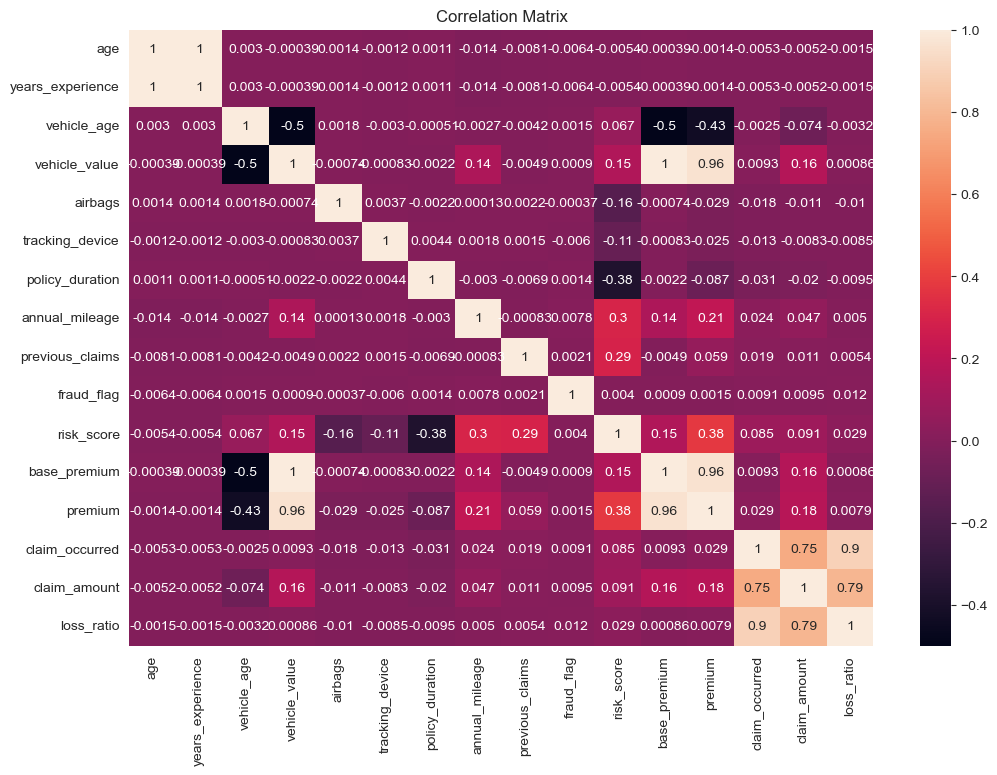

In [35]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

- The low correlation between risk score and claim occurrence (0.085) reflects the inherent stochastic nature of insurance claims. (Claims are probabilistic, not deterministic)

#### Feature Importance

In [36]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=["claim_occurred", "claim_amount"])
X = pd.get_dummies(X)

y = df["claim_occurred"]

model = RandomForestClassifier()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10)

claim_type_none         0.360901
loss_ratio              0.305309
claim_type_accident     0.269704
claim_type_theft        0.050611
claim_type_flood        0.010119
risk_score              0.000678
region_Nairobi          0.000410
traffic_density_high    0.000263
annual_mileage          0.000246
premium                 0.000234
dtype: float64

In [37]:
df["risk_band"] = pd.cut(df["risk_score"], bins=[0,0.4,0.7,1], labels=["Low","Medium","High"])

<Axes: xlabel='risk_band', ylabel='count'>

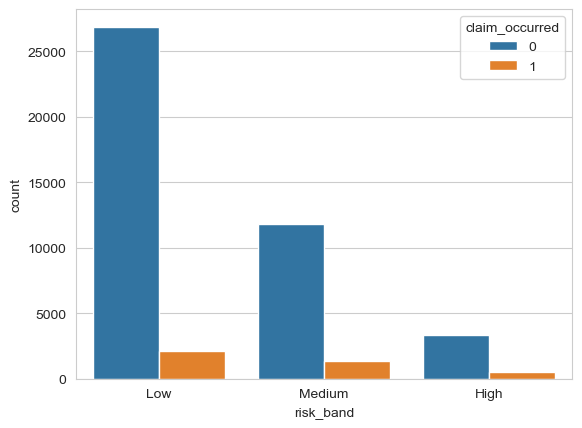

In [38]:
sns.countplot(x="risk_band", hue="claim_occurred", data=df)

#### Key Takeaways

1. The dataset reflects a **realistic insurance portfolio** with appropriate variation in demographics, vehicles, and behavior.
2. The **claim rate (~8%)** aligns with industry expectations, making it suitable for actuarial modeling.
3. Risk factors such as:
   - Age
   - Vehicle age
   - Mileage
   - Previous claims  
   are well represented and can drive meaningful underwriting decisions.
4. The presence of **heavy-tailed claim amounts** highlights the importance of separating:
   - Claim probability
   - Claim severity
5. The pricing structure appears **risk-adjusted**, providing a strong foundation for premium optimization and underwriting automation.